In [30]:
#step1: import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [31]:
#step2:import dataset
Credit_assess=pd.read_csv('https://github.com/ybifoundation/Dataset/raw/main/Credit%20Default.csv')

In [32]:
Credit_assess.head()

,Income,Age,Loan,Loan to Income,Default
0,66155.92510,59.017015,8106.532131,0.122537,0
1,34415.15397,48.117153,6564.745018,0.190752,0
2,57317.17006,63.108049,8020.953296,0.139940,0
3,42709.53420,45.751972,6103.642260,0.142911,0
4,66952.68885,18.584336,8770.099235,0.130990,1


In [33]:
Credit_assess.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Income          2000 non-null   float64
 1   Age             2000 non-null   float64
 2   Loan            2000 non-null   float64
 3   Loan to Income  2000 non-null   float64
 4   Default         2000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 78.3 KB


In [34]:
Credit_assess.describe()

,Income,Age,Loan,Loan to Income,Default
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,45331.600018,40.927143,4444.369695,0.098403,0.141500
std,14326.327119,13.262450,3045.410024,0.057620,0.348624
min,20014.489470,18.055189,1.377630,0.000049,0.000000
25%,32796.459720,29.062492,1939.708847,0.047903,0.000000
50%,45789.117310,41.382673,3974.719418,0.099437,0.000000
75%,57791.281670,52.596993,6432.410625,0.147585,0.000000
max,69995.685580,63.971796,13766.051240,0.199938,1.000000


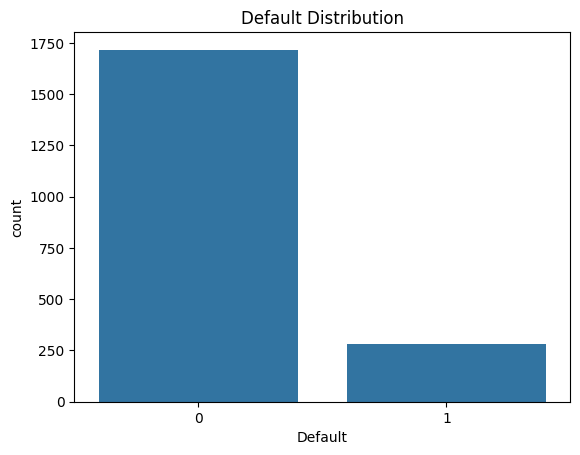

In [35]:
sns.countplot(x='Default', data=Credit_assess)
plt.title("Default Distribution")
plt.show()

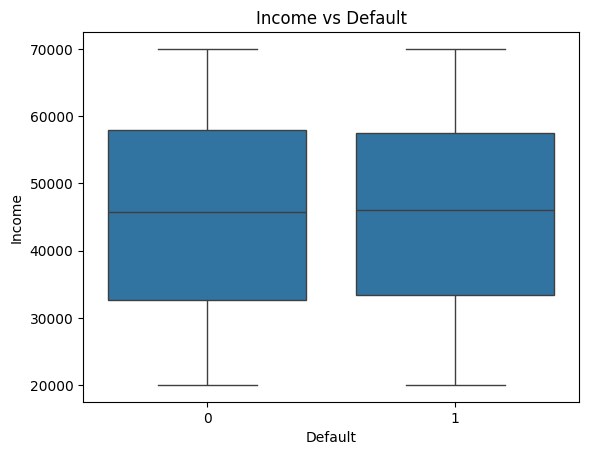

In [36]:
sns.boxplot(x='Default', y='Income', data=Credit_assess)
plt.title("Income vs Default")
plt.show()

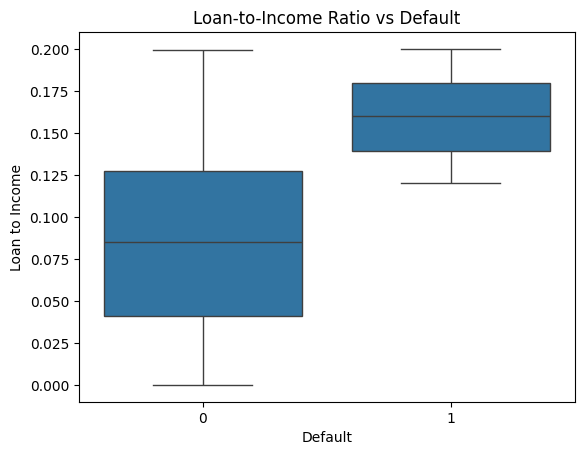

In [37]:
sns.boxplot(x='Default', y='Loan to Income', data=Credit_assess)
plt.title("Loan-to-Income Ratio vs Default")
plt.show()

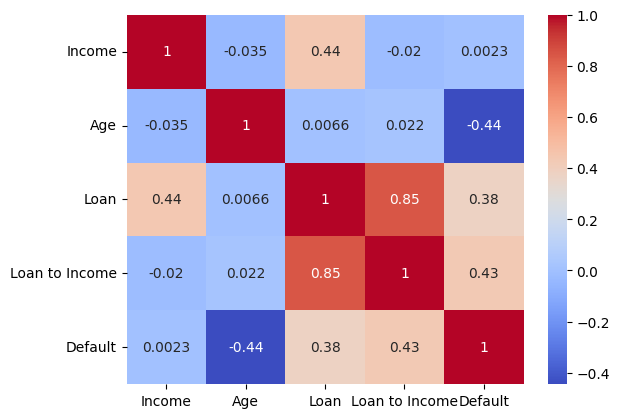

In [38]:
sns.heatmap(Credit_assess.corr(), annot=True, cmap='coolwarm')
plt.show()

In [39]:
Credit_assess.columns

Index(['Income', 'Age', 'Loan', 'Loan to Income', 'Default'], dtype='object')

In [40]:
#step3: define y and X
y=Credit_assess['Default']
X=Credit_assess[['Income', 'Age', 'Loan', 'Loan to Income']]

In [41]:

#step4: train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,random_state=2529)

In [42]:

#step5: model selection
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [43]:
model.coef_

array([[-2.38190492e-04, -3.47642263e-01,  1.72361397e-03,
         4.10940226e-01]])

In [44]:
pd.Series(model.coef_[0], index=X.columns)

,0
Income,-0.000238
Age,-0.347642
Loan,0.001724
Loan to Income,0.410940


In [45]:
#step6: prediction
y_pred=model.predict(X_test)

In [46]:

#step7: evaluation
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.95

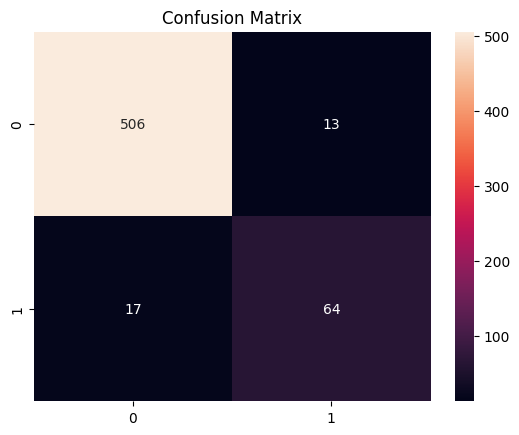

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       519
           1       0.83      0.79      0.81        81

    accuracy                           0.95       600
   macro avg       0.90      0.88      0.89       600
weighted avg       0.95      0.95      0.95       600



In [49]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.983467732343776


## Business Recommendations

- Applicants with high loan-to-income ratios should be considered high risk.
- Income level significantly impacts default probability.
- Risk-based interest rates can be designed using model output.
- The model can support automated risk scoring for credit decisions.
